# Data Exploration

## Project Introduction

This project investigates whether deep learning can transform sketch-like furniture edge maps into plausible RGB furniture images.

Each original furniture photograph is converted into a Canny edge representation. The edge map serves as the model input, while the corresponding photograph serves as the target image. This creates paired data suitable for supervised image-to-image generation.

The project extends the earlier [Furniture-Sketch-Classifier](https://github.com/Vanya2307/Furniture-Sketch-Classifier) study. That work used Canny edge detection, handcrafted HOG features, and classical machine learning models to classify five furniture categories. The present research shifts the task from sketch classification to sketch-to-image generation using deep learning. The earlier classifier provides a historical reference and will later be reused as an auxiliary semantic evaluator: generated RGB images will be converted into Canny edge maps and classified to test whether the intended furniture category is preserved.

Two generative models will be compared. A reconstruction-only U-Net trained with an $L_1$ objective will serve as the baseline. The Pix2Pix conditional GAN will use the same U-Net generator architecture together with a PatchGAN discriminator and will combine reconstruction and adversarial losses. This controlled comparison is intended to isolate the contribution of adversarial training to visual realism.

Data come from the Bonn Furniture Styles Dataset (Aggarwal et al., 2018). The initial scope includes the official `beds` and `dressers` categories because they are directly relevant to bedroom furniture design and provide a useful contrast in visual structure. Dressers tend to contain rectilinear forms and repeated drawer-like elements, whereas beds show greater variation in proportions, frames, and subtypes. Both categories contain multiple furniture subtypes and styles, which will be examined before the final cleaned dataset is defined.

**Dataset:** Bonn Furniture Styles Dataset, Aggarwal et al. (2018)  
**Original categories:** beds, chairs, dressers, lamps, sofas, tables  
**Initially selected categories:** beds, dressers  
**Input:** Canny edge map  
**Target:** corresponding RGB furniture photograph  
**Image size:** 256 × 256 pixels  
**Split:** predefined train / validation / test files  
**Planned comparison:** reconstruction-only U-Net vs. Pix2Pix using the same U-Net generator architecture

## Notebook Overview

Before generating paired images or training deep learning models, the dataset must be examined and validated carefully.

This notebook focuses on:

- loading and parsing the predefined dataset split files;
- selecting the `beds` and `dressers` categories;
- inspecting category, furniture-style, and product-subtype distributions;
- checking image paths, file integrity, and technical image properties;
- identifying duplicate paths, exact image duplicates, and possible near duplicates;
- verifying that duplicated content does not cause leakage between dataset splits;
- examining ambiguous product subtypes inside the official categories;
- defining a cleaned and reproducible dataset for paired image generation;
- saving portable metadata for the following notebooks.

## Setup and Imports

In [1]:
import hashlib
import random
import re
import sys
from pathlib import Path

import cv2
import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm


PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"OpenCV: {cv2.__version__}")

Python: 3.12.3
NumPy: 2.5.1
pandas: 3.0.3
OpenCV: 5.0.0


## Dataset Access and Split Loading

The analysis uses the original train, validation, and test definitions provided with the Bonn Furniture Styles Dataset. Raw images are not distributed with this repository. The notebook expects the extracted dataset to be available under `data/raw/bonn_furniture_styles/`.

In [5]:
from src.data_utils import (IMAGE_ROOT, SELECTED_CATEGORIES, load_dataset_splits,)


available_categories = sorted(path.name for path in IMAGE_ROOT.iterdir() if path.is_dir())

missing_categories = sorted(set(SELECTED_CATEGORIES) - set(available_categories))

if missing_categories:
    raise FileNotFoundError(f"Missing selected categories: {missing_categories}")

dataset_metadata = load_dataset_splits()

print(f"Categories found: {', '.join(available_categories)}")
print(f"Loaded records: {len(dataset_metadata):}")

display(
    dataset_metadata
    .groupby("split", sort=False)
    .size()
    .rename("images")
    .to_frame()
)

preview_columns = [
    "split",
    "relative_path",
    "category",
    "style",
    "product_subtype",
    "metadata_style",
    "metadata_field_count",
    "styles_match",

]

display(dataset_metadata[preview_columns].head())

Categories found: beds, chairs, dressers, lamps, sofas, tables
Loaded records: 90085


,images
split,
train,61273
validation,10800
test,18012


,split,relative_path,category,style,product_subtype,metadata_style,metadata_field_count,styles_match
0,train,houzz/dressers/Transitional/6609transitional-dressers.jpg,dressers,Transitional,Dressers,Transitional,6,True
1,train,houzz/dressers/Contemporary/625contemporary-dressers.jpg,dressers,Contemporary,Dressers,Contemporary,6,True
2,train,houzz/chairs/Midcentury/18157midcentury-armchairs-and-accent-chairs.jpg,chairs,Midcentury,Armchairs And Accent Chairs,Midcentury,6,True
3,train,houzz/lamps/Contemporary/1173contemporary-table-lamps.jpg,lamps,Contemporary,Table Lamps,Contemporary,6,True
4,train,houzz/lamps/Transitional/25709transitional-floor-lamps.jpg,lamps,Transitional,Floor Lamps,Transitional,6,True


In [6]:
#One final check of complete dataset

metadata_schema = (
    dataset_metadata["metadata_field_count"]
    .value_counts()
    .sort_index()
    .rename_axis("metadata_fields")
    .rename("records")
    .to_frame()
)
style_mismatches = (~dataset_metadata["styles_match"]).sum()

display(metadata_schema)
print(f"Style label mismatches: {style_mismatches:}")

,records
metadata_fields,
2,12254
6,77187
7,342
8,286
9,15
10,1


Style label mismatches: 0


In [7]:
#Records of two fields of metadata

two_field_records = dataset_metadata[
    dataset_metadata["metadata_field_count"] == 2
]

print(f"Records with two metadata fields: {len(two_field_records):}")

display(
    two_field_records[
        [
            "category",
            "product_subtype",
            "metadata_style",
            "metadata_attributes",
        ]
    ].head(10)
)

display(
    pd.crosstab(
        dataset_metadata["category"],
        dataset_metadata["metadata_field_count"],
    )
)

Records with two metadata fields: 12254


,category,product_subtype,metadata_style,metadata_attributes
5,tables,tables,Scandinavian,
18,beds,beds,Contemporary,
44,beds,beds,Transitional,
45,beds,beds,Contemporary,
49,beds,beds,Rustic,
54,beds,beds,Transitional,
73,lamps,lamps,Craftsman,
75,lamps,lamps,Craftsman,
88,beds,beds,Mediterranean,
101,beds,beds,Mediterranean,


metadata_field_count,2,6,7,8,9,10
category,,,,,,
beds,6578,0,0,0,0,0
chairs,261,21615,119,51,6,1
dressers,170,7678,13,11,0,0
lamps,4971,27104,135,185,7,0
sofas,19,4037,4,20,0,0
tables,255,16753,71,19,2,0


### Observation

- All 90085 split records were loaded successfully: 61273 training, 10800 validation, and 18012 test records.
- All six expected furniture category directories were found.
- The metadata schema varies from two to ten fields. Most records contain six fields (77187; 85.7%), while 12254 records (13.6%) contain only two.
- Metadata availability is strongly category-dependent. Every bed record contains only two fields, and lamps account for another 4971 two-field records. In contrast, most dresser records contain six fields.
- The two-field records contain only product subtype and furniture style; optional product attributes are absent. This does not affect image generation because these attributes are not used as model inputs, but it limits metadata-based analysis, especially for beds.
- The official furniture category is therefore derived from the image directory path rather than the optional metadata.
- Style labels agree across the split files, directory paths, and metadata for all records.
- No records are removed during loading. Duplicate paths, duplicate images, and cross-split leakage will be investigated separately before the cleaned subset is created.

## Category and Style Distribution

In [8]:
split_order = ["train", "validation", "test"]

category_counts = pd.crosstab(
    dataset_metadata["category"],
    dataset_metadata["split"],
).reindex(columns=split_order, fill_value=0)

category_counts["total"] = category_counts.sum(axis=1)
category_counts["share_percent"] = (category_counts["total"] / category_counts["total"].sum() * 100).round(1)

category_counts = category_counts.sort_values("total", ascending=False,)

display(category_counts)

split,train,validation,test,total,share_percent
category,,,,,
lamps,22036,3887,6479,32402,36.0
chairs,14997,2643,4413,22053,24.5
tables,11633,2063,3404,17100,19.0
dressers,5359,927,1586,7872,8.7
beds,4472,791,1315,6578,7.3
sofas,2776,489,815,4080,4.5


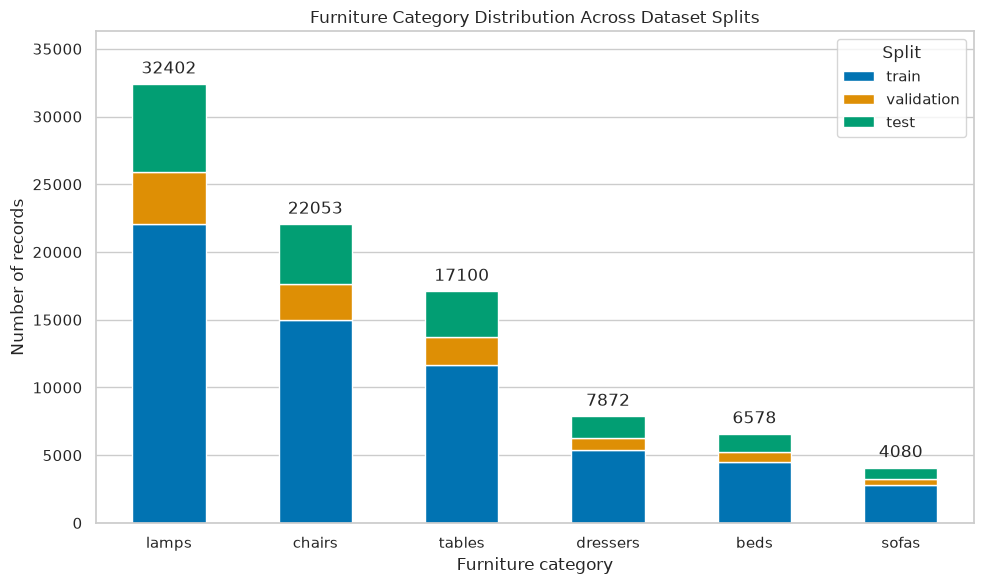

In [11]:
#The category visualization

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


plot_data = category_counts[split_order]

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=sns.color_palette("colorblind", len(split_order)),
    edgecolor="white",
)

offset = category_counts["total"].max() * 0.015

for position, total in enumerate(category_counts["total"]):
    ax.text(
        position,
        total + offset,
        str(total),
        ha="center",
        va="bottom",
    )


ax.set_title("Furniture Category Distribution Across Dataset Splits")
ax.set_xlabel("Furniture category")
ax.set_ylabel("Number of records")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Split")
ax.grid(axis="x", visible=False)
ax.set_ylim(0, category_counts["total"].max() * 1.12)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "category_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### Observation

- The complete dataset is strongly imbalanced. Lamps represent 36.0% of all records, while sofas represent only 4.5%.
- Beds and dressers account for 7.3% and 8.7% of the complete dataset. Their totals are relatively close, with 6578 bed records and 7872 dresser records.
- The train / validation / test proportions remain similar across categories. Approximately 68% of each category belongs to training, 12% to validation, and 20% to testing.
- The predefined split structure will be preserved, but the final beds/dressers subset may require balancing after integrity and duplicate checks are completed.

category,beds,dressers,total
style,,,
Traditional,1397,2086,3483
Transitional,1719,1622,3341
Contemporary,1953,1284,3237
Farmhouse,91,568,659
Modern,380,256,636
Rustic,239,378,617
Asian,52,485,537
Midcentury,130,307,437
Craftsman,188,128,316


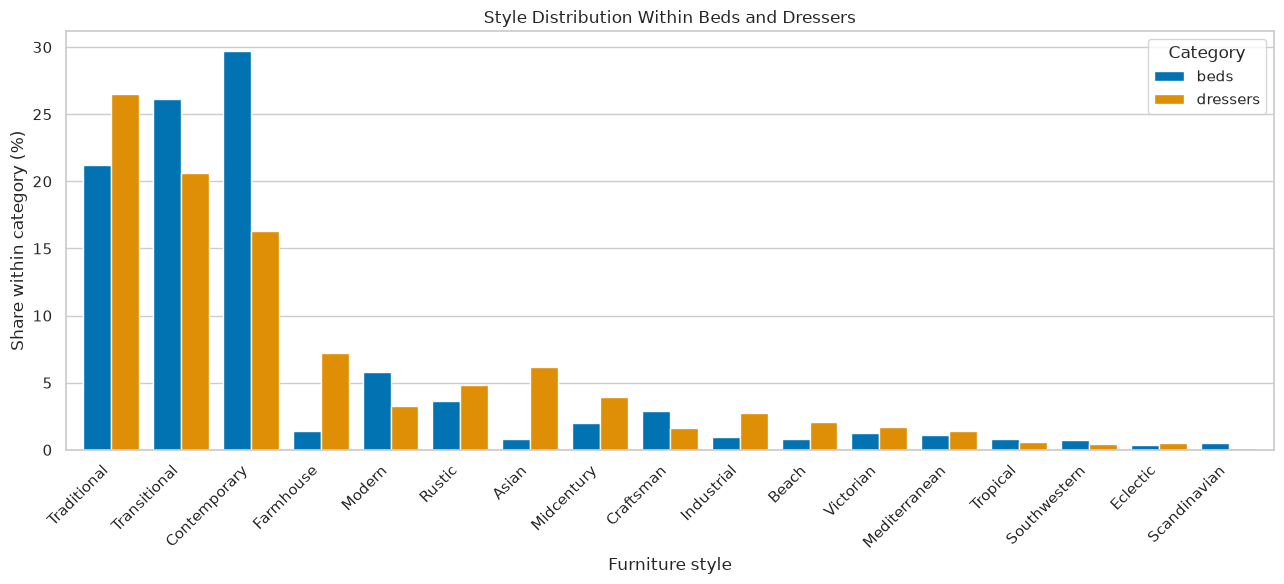

In [12]:
#The style analysis

selected_metadata = dataset_metadata[dataset_metadata["category"].isin(SELECTED_CATEGORIES)].copy()

style_counts = pd.crosstab(
    selected_metadata["style"],
    selected_metadata["category"],
).reindex(
    columns=list(SELECTED_CATEGORIES),
    fill_value=0,
)

style_counts["total"] = style_counts.sum(axis=1)

style_counts = style_counts.sort_values("total", ascending=False)

display(style_counts)


style_percent = (style_counts[list(SELECTED_CATEGORIES)].div(style_counts[list(SELECTED_CATEGORIES)].sum(axis=0), axis=1,) * 100)

ax = style_percent.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.8,
    color=sns.color_palette("colorblind", 2),
)

ax.set_title("Style Distribution Within Beds and Dressers")
ax.set_xlabel("Furniture style")
ax.set_ylabel("Share within category (%)")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
)

ax.legend(title="Category")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "style_distribution_beds_dressers.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


### Observation

- All 17 furniture styles are represented in both selected categories, but their distributions are strongly imbalanced.
- Traditional, Transitional, and Contemporary dominate the selected data. Together they contain 10061 records, representing 69.6% of all beds and dressers.
- Beds are concentrated most strongly in Contemporary (29.7%), Transitional (26.1%), and Traditional (21.2%). Together these styles represent 77.1% of all bed records.
- Dressers are led by Traditional (26.5%), Transitional (20.6%), and Contemporary (16.3%). Together they represent 63.4% of dresser records.
- Some styles show clear category differences. Farmhouse and Asian are substantially more common among dressers, while Contemporary is more common among beds.
- Scandinavian, Eclectic, Southwestern, and Tropical contain very few records. Their results may therefore be less reliable during style-specific evaluation.
- The final subset should balance beds and dressers while preserving as much style coverage as possible. Fully balancing all 17 styles would remove too much usable data, so the sampling strategy will be decided after cleaning.

## Product Subtype Exploration

In [15]:
subtype_counts = (
    selected_metadata
    .groupby(["category", "product_subtype"], dropna=False,)
    .size()
    .rename("records")
    .reset_index()
    .sort_values(["category", "records"], ascending=[True, False],)
)

subtype_summary = (
    selected_metadata
    .groupby("category")["product_subtype"]
    .nunique()
    .rename("unique_subtypes")
    .to_frame()
)

display(subtype_summary)
display(subtype_counts)


,unique_subtypes
category,
beds,1
dressers,24


,category,product_subtype,records
0,beds,beds,6578
11,dressers,Dressers,6310
19,dressers,Nightstands And Bedside Tables,386
20,dressers,Side Tables And End Tables,313
7,dressers,Console Tables,189
3,dressers,Buffets And Sideboards,175
1,dressers,Accent Chests And Cabinets,170
24,dressers,dressers,170
12,dressers,Entertainment Centers And Tv Stands,71
22,dressers,Storage Cabinets,19


The official category folders may contain several related product types. Product subtype information is therefore examined to determine whether all records match the intended project scope.

The raw metadata contains only one generic subtype for beds but multiple subtypes for dressers. Some dresser labels also differ only in capitalization, such as `Dressers` and `dressers`. The subtype text is normalized for comparison while the original value is preserved.

This analysis will show how many records describe actual dressers and how many represent related products such as nightstands, side tables, cabinets, or console tables. No records are removed at this stage.

In [16]:
selected_metadata["product_subtype_normalized"] = (selected_metadata["product_subtype"].str.strip().str.casefold())

normalized_subtype_counts = (
    selected_metadata
    .groupby(["category", "product_subtype_normalized"])
    .size()
    .rename("records")
    .reset_index()
    .sort_values(["category", "records"], ascending=[True, False],)
)

display(normalized_subtype_counts)



,category,product_subtype_normalized,records
0,beds,beds,6578
11,dressers,dressers,6480
19,dressers,nightstands and bedside tables,386
20,dressers,side tables and end tables,313
7,dressers,console tables,189
3,dressers,buffets and sideboards,175
1,dressers,accent chests and cabinets,170
12,dressers,entertainment centers and tv stands,71
22,dressers,storage cabinets,19
2,dressers,armoires and wardrobes,12


The metadata does not provide detailed subtypes for beds because every bed record uses the generic label `beds`. However, the filenames contain more specific product descriptions.

The following analysis removes the numerical image identifier and furniture-style prefix from each bed filename. The remaining text is treated as a raw filename descriptor. This may reveal subtypes such as panel beds, platform beds, bunk beds, daybeds, and loft beds.

Filename descriptors are extracted for all selected categories so that the same process can support additional categories in future experiments. The current analysis focuses on beds because their metadata contains only a generic product subtype.

In [20]:
def extract_filename_descriptor(relative_path, style):
    """Extract the product description encoded in a filename."""

    filename_stem = Path(relative_path).stem.casefold()
    filename_stem = re.sub(r"^\d+", "", filename_stem)

    style_prefix = (style.strip().casefold().replace(" ", "-"))

    if filename_stem.startswith(style_prefix):
        filename_stem = filename_stem[len(style_prefix):]

    return filename_stem.lstrip("-")


selected_metadata["filename_descriptor"] = [
    extract_filename_descriptor(relative_path, style)
    for relative_path, style in zip(
        selected_metadata["relative_path"],
        selected_metadata["style"],
    )
]

descriptor_summary = (
    selected_metadata
    .groupby("category")["filename_descriptor"]
    .nunique()
    .rename("unique_filename_descriptor")
    .to_frame()
)

descriptor_counts = (
    selected_metadata
    .groupby(["category", "filename_descriptor"])
    .size()
    .rename("records")
    .reset_index()
    .sort_values(["category", "records"], ascending=[True, False],)
)

display(descriptor_summary)
display(descriptor_counts[descriptor_counts["category"] == "beds"].head(30))

,unique_filename_descriptor
category,
beds,34
dressers,107


,category,filename_descriptor,records
18,beds,panel-beds,2044
19,beds,platform-beds,1631
14,beds,kids-beds,808
6,beds,bunk-beds,705
10,beds,daybeds,316
20,beds,sleigh-beds,201
7,beds,canopy-beds,190
15,beds,loft-beds,174
4,beds,beds,144
13,beds,kids-bedroom-furniture-sets,87


The filename analysis provides useful subtype information for beds, but it also reveals minor naming inconsistencies. Several descriptors contain an additional `style-` prefix, such as `style-panel-beds` and `style-bunk-beds`. These labels describe the same product types as `panel-beds` and `bunk-beds`.

The additional prefix is removed in a separate normalized column. The original filename descriptor is preserved so that the transformation remains traceable.

In [22]:
selected_metadata["filename_descriptor_normalized"] = (selected_metadata["filename_descriptor"].str.replace(r"^style-", "", regex=True))

bed_subtype_counts = (
    selected_metadata
    .loc[selected_metadata["category"] == "beds", "filename_descriptor_normalized",]
    .value_counts()
    .rename_axis("bed_subtype")
    .rename("records")
    .to_frame()
)

bed_subtype_counts["share_percent"] = (
    bed_subtype_counts["records"] / bed_subtype_counts["records"].sum() * 100
).round(2)

display(bed_subtype_counts)

,records,share_percent
bed_subtype,,
panel-beds,2074,31.53
platform-beds,1633,24.83
kids-beds,811,12.33
bunk-beds,709,10.78
daybeds,317,4.82
sleigh-beds,203,3.09
canopy-beds,194,2.95
loft-beds,175,2.66
beds,145,2.20


Several rare filename descriptors appear unrelated, malformed, or too general for the bed category. Because filename text alone may be misleading, these records are inspected visually before any cleaning decision is made.

,split,relative_path,filename_descriptor_normalized
15367,train,houzz/beds/Craftsman/4866craftsman-bed.jpg,bed
29738,train,houzz/beds/Modern/beds222.jpg,beds222
37733,train,houzz/beds/Mediterranean/40939mediterranean-throws.jpg,throws
49556,train,houzz/beds/Farmhouse/34516farmhouse-cribs.jpg,cribs
51482,train,houzz/beds/Transitional/1743transitional-dressers.jpg,dressers
58528,train,houzz/beds/Rustic/4754rustic-bed.jpg,bed
65632,validation,houzz/beds/Asian/20750asian-comforters-and-comforter-sets.jpg,comforters-and-comforter-sets
72366,test,houzz/beds/Transitional/5100transitional-bedroom-furniture-sets.jpg,bedroom-furniture-sets
72584,test,houzz/beds/Modern/29423modern-bedroom-furniture.jpg,bedroom-furniture
73340,test,houzz/beds/Craftsman/28376craftsman-cribs.jpg,cribs


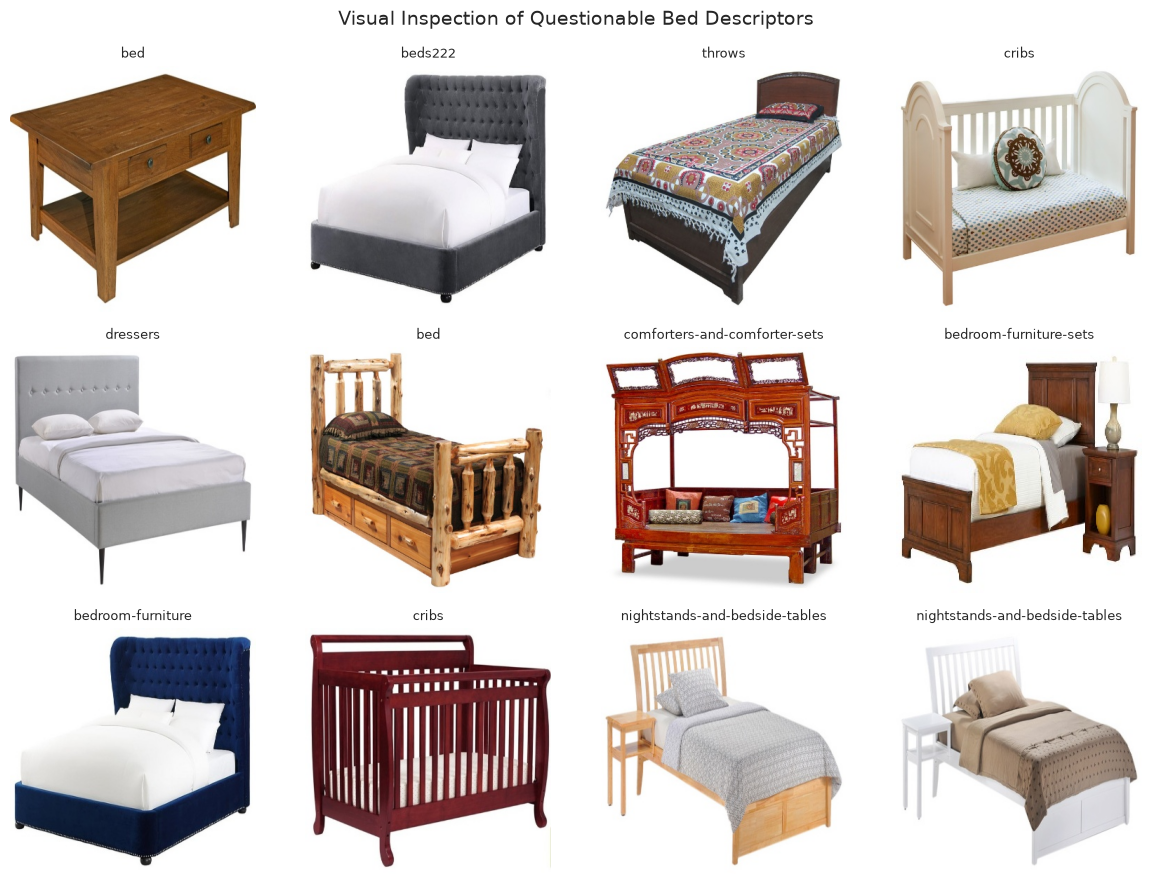

In [25]:
from src.data_utils import DATASET_ROOT

questionable_descriptors = [
    "bed",
    "cribs",
    "nightstands-and-bedside-tables",
    "beds222",
    "throws",
    "dressers",
    "comforters-and-comforter-sets",
    "bedroom-furniture-sets",
    "bedroom-furniture",
]

questionable_beds = selected_metadata[
    (selected_metadata["category"] == "beds") & (selected_metadata["filename_descriptor_normalized"].isin(questionable_descriptors))
].copy()

display(questionable_beds[
    [
        "split",
        "relative_path",
        "filename_descriptor_normalized",
    ]
])

n_columns = 4
n_rows = int(np.ceil(len(questionable_beds) / n_columns))

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(12, 3 * n_rows),
)

axes = np.asarray(axes).reshape(-1)

for axis, (_, record) in zip(axes, questionable_beds.iterrows()):
    image_path = DATASET_ROOT / record["relative_path"]


    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))

    axis.set_title(record["filename_descriptor_normalized"], fontsize=9)
    axis.axis("off")


for axis in axes[len(questionable_beds):]:
    axis.axis("off")

fig.suptitle("Visual Inspection of Questionable Bed Descriptors", fontsize=14)

plt.tight_layout()
plt.show()


### Observations

The visual inspection identified one incorrectly categorized image. The record `houzz/beds/Craftsman/4866craftsman-bed.jpg` contains a side table rather than a bed and should be excluded from the cleaned dataset.

The remaining questionable records contain beds, cribs, or bedroom furniture sets in which a bed is the main object. Their filename descriptors are sometimes incomplete or misleading, but the images remain relevant to the selected category.

The two records with the descriptor `bed` demonstrate why cleaning cannot be based only on filename text: one is incorrectly categorized, while the other contains a valid bed. Therefore, individual records will be excluded using their exact relative paths after visual confirmation.

## Image Integrity Check

Before generating paired edge and RGB images, the selected source files must be checked for missing, unreadable, or technically unusual images.

Each unique file is inspected once. The scan records its dimensions, colour mode, format, file size, SHA256 hash, and perceptual hash. The SHA256 and perceptual hashes will later be reused for exact and near-duplicate analysis.

Scanning unique paths avoids reading the same physical file repeatedly if its path appears more than once in the split metadata.

In [28]:
import importlib

from src import data_utils

importlib.reload(data_utils)

unique_selected_paths = (selected_metadata["relative_path"].drop_duplicates().sort_values())

inspection_records = [
    data_utils.inspect_image_file(relative_path)
    for relative_path in tqdm(
        unique_selected_paths,
        desc="Inspecting selected images",
    )
]

image_inspection = pd.DataFrame(inspection_records)

integrity_summary = pd.Series(
    {
        "selected_records": len(selected_metadata),
        "unique_paths_scanned": len(image_inspection),
        "existing_files": int(image_inspection["file_exists"].sum()),
        "readable_images": int(image_inspection["image_readable"].sum()),
        "missing_or_unreadable": int(
            (~image_inspection["image_readable"]).sum()
        ),
    },
    name="count",
).to_frame()

display(integrity_summary)

Inspecting selected images:   0%|          | 0/14449 [00:00<?, ?it/s]

,count
selected_records,14450
unique_paths_scanned,14449
existing_files,14449
readable_images,14449
missing_or_unreadable,0


In [29]:
problematic_images = image_inspection.loc[
    ~image_inspection["image_readable"],
    [
        "relative_path",
        "file_exists",
        "inspection_error",
    ],
]

print(f"Problematic images: {len(problematic_images)}")
display(problematic_images)

Problematic images: 0


,relative_path,file_exists,inspection_error


In [30]:
#Technical properties

dimension_counts = (image_inspection.loc[image_inspection["image_readable"]]
    .groupby(["width", "height"])
    .size()
    .rename("images")
    .sort_values(ascending=False)
    .reset_index()
)

format_counts = (image_inspection.loc[image_inspection["image_readable"]]
    .groupby(["image_format", "image_mode"])
    .size()
    .rename("images")
    .sort_values(ascending=False)
    .reset_index()
)

print(f"Unique image dimensions: {len(dimension_counts)}")
display(dimension_counts.head(20))

print("Image formats and colour modes:")
display(format_counts)

Unique image dimensions: 2


,width,height,images
0,350,350,7912
1,224,224,6537


Image formats and colour modes:


,image_format,image_mode,images
0,JPEG,RGB,14449


In [31]:
#Attaching the results to the selected metadata

selected_metadata = selected_metadata.merge(
    image_inspection,
    on="relative_path",
    how="left",
    validate="many_to_one",
)

print(f"Selected records after metadata merge: {len(selected_metadata)}")

Selected records after metadata merge: 14450


### Observations

All 14449 unique image files referenced by the selected metadata exist and can be opened successfully. No missing, corrupted, or unreadable images were identified.

The images use two original resolutions: 7912 images are 350 x 350 pixels and 6537 images are 224 x 224 pixels. All files are square RGB JPEG images. The consistent aspect ratio means that they can be resized to 256 x 256 pixels without cropping or geometric distortion during paired-data preparation.

The selected metadata contains 14450 records but only 14449 unique paths. This indicates that one path is repeated and requires investigation during duplicate and leakage analysis.

No files need to be excluded for technical image-integrity reasons.

## Duplicate and Leakage Analysis

Duplicate content can make evaluation results misleading, particularly when the same or nearly identical image appears in different dataset splits.

The analysis proceeds from strict to increasingly visual definitions of duplication:

1. repeated relative paths in the split metadata;
2. exact file duplicates identified by SHA256;
3. visually similar files identified by perceptual hashes;
4. duplicate content shared between train, validation, and test splits.

Duplicates are measured before any records are removed so that the original dataset structure remains documented.

### Duplicate Paths

The first check searches for repeated relative paths. A repeated path may occur more than once inside one split or may be assigned to multiple splits.

In [33]:
duplicate_path_rows = (
    selected_metadata.loc[selected_metadata.duplicated(subset="relative_path", keep=False,)].sort_values(["relative_path", "split"])
)

duplicate_path_summary = (
    duplicate_path_rows
    .groupby("relative_path")
    .agg(
        records=("relative_path", "size"), split_count=("split", "nunique"), splits=("split", lambda values: ", ".join(sorted(set(values)))),
        category=("category", "first"),
    )
    .reset_index()
)

print(f"Repeated paths: {len(duplicate_path_summary)}")
print(f"Records using repeated paths: {len(duplicate_path_rows)}")

display(duplicate_path_rows[
    [
        "split",
        "relative_path",
        "category",
        "style",
        "sha256",

    ]
])

Repeated paths: 1
Records using repeated paths: 2


,split,relative_path,category,style,sha256
12913,test,houzz/dressers/Asian/dresser.jpg,dressers,Asian,607ed5040a3300bfad2993ffca85d96ae671473b9ef80fc9004d8f47aeb6691b
14339,test,houzz/dressers/Asian/dresser.jpg,dressers,Asian,607ed5040a3300bfad2993ffca85d96ae671473b9ef80fc9004d8f47aeb6691b


#### Observations

One repeated relative path was identified. The file `houzz/dressers/Asian/dresser.jpg` appears twice in the test split.

Because both records belong to the same split, this duplication does not create cross-split leakage. However, retaining both records would give this image additional weight during evaluation. One occurrence will therefore be retained and the second metadata record will be removed during dataset cleaning.

The exact-duplicate analysis uses unique file paths, so this repeated metadata entry is not counted again as a separate physical file.

### Exact Image Duplicates

Different paths or filenames may still refer to files containing exactly the same bytes. SHA256 hashes are therefore compared across all unique image paths.

Images with the same SHA256 hash are exact file duplicates. Duplicate groups that occur across multiple dataset splits represent direct train, validation, or test leakage.

In [38]:
file_metadata = (
    selected_metadata
    .groupby("relative_path", as_index=False)
    .agg(
        category=("category", "first"),
        style=("style", "first"),
        sha256=("sha256", "first"),
        perceptual_hash=("perceptual_hash", "first"),
        split_labels=(
            "split",
            lambda values: tuple(sorted(set(values))),
        ),
    )
)


def combine_split_labels(values):
    labels = {label for split_labels in values for label in split_labels}

    return ", ".join(sorted(labels))


def count_split_labels(values):
    return len(
        {
            label
            for split_labels in values
            for label in split_labels
        }
    )


duplicate_sha256_values = file_metadata.loc[
    file_metadata.duplicated(
        subset="sha256",
        keep=False,
    ),
    "sha256",
].unique()

exact_duplicate_groups = (
    file_metadata.loc[
        file_metadata["sha256"].isin(duplicate_sha256_values)
    ]
    .groupby("sha256")
    .agg(
        files=("relative_path", "nunique"),
        split_count=("split_labels", count_split_labels),
        splits=("split_labels", combine_split_labels),
        category_count=("category", "nunique"),
        categories=(
            "category",
            lambda values: ", ".join(sorted(set(values))),
        ),
    )
    .reset_index()
    .sort_values(
        ["split_count", "files"],
        ascending=False,
    )
    .reset_index(drop=True)
)

exact_duplicate_groups.insert(
    0,
    "duplicate_group",
    range(1, len(exact_duplicate_groups) + 1),
)

exact_duplicate_files = file_metadata.merge(
    exact_duplicate_groups[
        [
            "duplicate_group",
            "sha256",
        ]
    ],
    on="sha256",
    how="inner",
).sort_values(
    [
        "duplicate_group",
        "relative_path",
    ]
)

redundant_exact_files = int(
    (exact_duplicate_groups["files"] - 1).sum()
)

cross_split_exact_groups = exact_duplicate_groups.loc[
    exact_duplicate_groups["split_count"] > 1
]

print(f"Exact duplicate groups: {len(exact_duplicate_groups)}")
print(
    "Files belonging to exact duplicate groups: "
    f"{len(exact_duplicate_files)}"
)
print(f"Redundant exact files: {redundant_exact_files}")
print(
    "Exact duplicate groups crossing splits: "
    f"{len(cross_split_exact_groups)}"
)

display(
    exact_duplicate_groups[
        [
            "duplicate_group",
            "files",
            "split_count",
            "splits",
            "category_count",
            "categories",
        ]
    ].head(20)
)

display(
    exact_duplicate_files[
        [
            "duplicate_group",
            "split_labels",
            "category",
            "style",
            "relative_path",
        ]
    ].head(40)
)

Exact duplicate groups: 104
Files belonging to exact duplicate groups: 208
Redundant exact files: 104
Exact duplicate groups crossing splits: 43


,duplicate_group,files,split_count,splits,category_count,categories
0,1,2,2,"test, train",1,dressers
1,2,2,2,"test, train",1,beds
2,3,2,2,"train, validation",1,dressers
3,4,2,2,"test, validation",1,beds
4,5,2,2,"train, validation",1,dressers
5,6,2,2,"train, validation",1,dressers
6,7,2,2,"test, train",1,dressers
7,8,2,2,"test, train",1,dressers
8,9,2,2,"test, train",1,beds
9,10,2,2,"test, train",1,dressers


,duplicate_group,split_labels,category,style,relative_path
157,1,"(test,)",dressers,Farmhouse,houzz/dressers/Farmhouse/33597farmhouse-dressers.jpg
178,1,"(train,)",dressers,Farmhouse,houzz/dressers/Farmhouse/5284farmhouse-dressers.jpg
62,2,"(test,)",beds,Traditional,houzz/beds/Traditional/6207traditional-sleigh-beds.jpg
99,2,"(train,)",beds,Transitional,houzz/beds/Transitional/9528transitional-sleigh-beds.jpg
112,3,"(validation,)",dressers,Asian,houzz/dressers/Asian/20064asian-dressers.jpg
127,3,"(train,)",dressers,Asian,houzz/dressers/Asian/5035asian-dressers.jpg
28,4,"(test,)",beds,Farmhouse,houzz/beds/Farmhouse/8384farmhouse-bunk-beds.jpg
102,4,"(validation,)",beds,Transitional,houzz/beds/Transitional/9567transitional-bunk-beds.jpg
110,5,"(train,)",dressers,Asian,houzz/dressers/Asian/19782asian-dressers.jpg
121,5,"(validation,)",dressers,Asian,houzz/dressers/Asian/2769asian-dressers.jpg


#### Observations

The SHA256 analysis identified 104 exact duplicate groups. Every group contains two files, meaning that 208 unique paths are involved and 104 files are redundant copies.

Of these groups, 43 cross dataset split boundaries. These files create direct leakage because identical image content occurs in training and evaluation data. Although the redundant files represent only approximately 0.72% of the unique selected files, the cross-split duplicates could make validation and test results appear better than they really are.

Several identical files are stored under different filenames, styles, or splits. This confirms that paths and directory labels alone are not sufficient for identifying duplicate content.

The original records remain unchanged during exploration. During cleaning, every exact duplicate group will be assigned to only one split and only one representative file will be retained.